# **Machine Learning Analysis of Atmospheric CO₂ Time Series**

In the previous analysis, we used a **full time-series analysis workflow** to analyze, model, and forecast atmospheric CO₂ concentrations. The results were encouraging, with the selected models **generalizing well to unseen observations** and producing forecasts that performed strongly against the holdout data.

### Machine Learning Approach

In this analysis, we will use the **same NOAA Mauna Loa CO₂ dataset** to explore how a range of **machine learning methods** can be applied to the forecasting problem. The analysis will follow the full machine learning workflow, including **data analysis, feature engineering, model implementation, tuning, evaluation, and forecasting**.

The methods covered will include:

- **Linear Regression**
- **Linear Discriminant Analysis (LDA)**
- **Quadratic Discriminant Analysis (QDA)**
- **Tree-based methods**, including bagging and random forests
- **Boosting methods**

Deep neural networks could also be explored as another model family, but they will **not be covered** in this analysis.

### Model Tuning and Evaluation

Each method will be appropriately tuned using approaches such as **grid search, random search, or similar optimization strategies**. Model performance will be evaluated using **chronological cross-validation**, rather than randomly splitting the observations, so that the temporal ordering of the dataset is preserved.

After selecting the **best-performing model**, it will be used to generate a **24-month future forecast**. This forecast will be evaluated against a **24-month holdout period** that the model has not seen during training and will also be compared with the forecasts produced by the **time-series models from the previous analysis**.

### Univariate Machine Learning

A key distinction in this analysis is that we are applying machine learning to a **univariate time series**. Unlike many machine learning applications that use rich multivariate datasets containing numerous explanatory variables, the models here will primarily learn patterns from the **historical CO₂ concentrations themselves**, rather than directly incorporating multiple external variables or physical drivers of atmospheric CO₂. How the historical series is transformed into predictive features, and the implications of this approach, will be discussed later in the **feature engineering** section.

## **1. Loading and Preparing the CO₂ Data**
The dataset is loaded into a `pandas DataFrame`, and a proper monthly date index is created from the `year` and `month` columns. The data is then converted to a **monthly time-series frequency** (`MS`), indicating that observations occur at the start of each month.

In [1]:
import pandas as pd

df = pd.read_csv("../data/co2_mm_mlo.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS") #tells pandas that observations occur at the start of every month

print(df.head())

            year  month  decimal date  average  deseasonalized  ndays  sdev  \
date                                                                          
1958-03-01  1958      3     1958.2027   315.71          314.44     -1 -9.99   
1958-04-01  1958      4     1958.2877   317.45          315.16     -1 -9.99   
1958-05-01  1958      5     1958.3699   317.51          314.69     -1 -9.99   
1958-06-01  1958      6     1958.4548   317.27          315.15     -1 -9.99   
1958-07-01  1958      7     1958.5370   315.87          315.20     -1 -9.99   

             unc  
date              
1958-03-01 -0.99  
1958-04-01 -0.99  
1958-05-01 -0.99  
1958-06-01 -0.99  
1958-07-01 -0.99  


### **1.1 Chronological Train-Holdout Split**
Because this is a **time-series dataset**, the observations must remain in chronological order. Randomly splitting the data could introduce **data leakage**, as information from the future could enter the training set. Therefore, the last 24 months are reserved as a **holdout set** for evaluating the model's 24-month-ahead forecasts.

In [2]:
# Number of months to hold out
holdout_months = 24

# Split the data
train = df.iloc[:-holdout_months].copy()
holdout = df.iloc[-holdout_months:].copy()

# Check the split
print("Training data:")
print(train.index.min(), "to", train.index.max())
print(f"Number of observations: {len(train)}")

print("\nHoldout data:")
print(holdout.index.min(), "to", holdout.index.max())
print(f"Number of observations: {len(holdout)}")

Training data:
1958-03-01 00:00:00 to 2024-07-01 00:00:00
Number of observations: 797

Holdout data:
2024-08-01 00:00:00 to 2026-07-01 00:00:00
Number of observations: 24


## 2. **Feature Engineering for Machine Learning**

Since the target variable is a numerical value (the observed monthly CO₂ concentration), defined as `average`, this is a **regression problem**. The objective is to use previously observed information to predict the CO₂ concentration for a future month. The most important consideration when applying machine learning to this dataset is that it is a **univariate time series**. We therefore need to transform the temporal structure into features that conventional machine learning models can use.

### Target Variable

The target variable will be: $\text{Target} = \text{average}$ where `average` represents the observed monthly mean atmospheric CO₂ concentration in ppm.

### Cyclical Month Features

The `month` variable contains important seasonal information, but treating it as an ordinary numeric variable is not ideal. For example, December (`12`) and January (`1`) are numerically far apart even though they are adjacent in the annual seasonal cycle. To represent this cyclical relationship, month will be encoded using **sine and cosine transformations**. This allows the models to recognize that December and January are close together in the seasonal cycle:

$$
\text{month\_sin} = \sin\left(\frac{2\pi \cdot \text{month}}{12}\right)
$$

$$
\text{month\_cos} = \cos\left(\frac{2\pi \cdot \text{month}}{12}\right)
$$

### Lag Features

For a univariate time series, the historical values of the target provide some of the most useful predictive information. We therefore create **lag features**, where each feature represents an observed CO₂ concentration from a previous month. For example:

- `lag_1` = CO₂ concentration one month ago
- `lag_2` = CO₂ concentration two months ago
- `lag_3` = CO₂ concentration three months ago
- `lag_6` = CO₂ concentration six months ago
- `lag_8` = CO₂ concentration eight months ago
- `lag_10` = CO₂ concentration ten months ago
- `lag_12` = CO₂ concentration twelve months ago

The 12-month lag is particularly useful because it allows the models to compare the current month with the **same month in the previous year**. The resulting machine learning problem can therefore learn relationships such as:

$$
CO_2(t) = f\left(CO_2(t-1), CO_2(t-2), \ldots, CO_2(t-12), \text{seasonality}\right)
$$

This approach is also appropriate for forecasting because, when predicting a future observation, previously observed CO₂ values are available and can legitimately be used as predictors.

### Rolling Features

We can also provide the models with information about the recent level and variability of the series using **rolling statistics**, such as a rolling mean and rolling standard deviation. For example, a 12-month rolling mean summarizes the recent average CO₂ concentration, while a rolling standard deviation provides information about recent variability.

Importantly, these rolling statistics must be calculated using **past observations only**. The current target value must never be included in its own features, as this would introduce **data leakage**.

### Avoiding Data Leakage

The **24-month holdout period will remain completely untouched** during feature engineering and model development. Feature engineering will first be performed on the training data, and the resulting feature structure will then be applied to the holdout data when it is finally used for evaluation. This ensures that the machine learning models only learn from information that would actually have been available at the time of prediction.

**Note:**
We keep the feature engineering in a function so that the exact same transformations can later be applied consistently to the holdout set and, eventually, to the 24-month forecasting process.

In [3]:
import numpy as np
import pandas as pd

# Feature Engineering Function

def create_ml_features(data):
    """
    Create machine-learning features from the CO₂ time series.

    Target:
        average

    Features:
        - Cyclical month representation
        - Lagged CO₂ concentrations
        - Rolling mean
        - Rolling standard deviation
    """

    df_ml = data.copy()

    # 1. Cyclical month features
    df_ml["month_sin"] = np.sin(
        2 * np.pi * df_ml["month"] / 12
    )
    df_ml["month_cos"] = np.cos(
        2 * np.pi * df_ml["month"] / 12
    )

    # 2. Lag features
    lags = [1, 2, 3, 6, 8, 10, 12, 24, 36, 48, 60]

    for lag in lags:
        df_ml[f"lag_{lag}"] = df_ml["average"].shift(lag)

    # 3. Rolling statistics
    # Shift by 1 first so that the current target value is NOT included in the rolling statistics.

    df_ml["rolling_mean_12"] = (
        df_ml["average"]
        .shift(1)
        .rolling(window=12)
        .mean()
    )
    df_ml["rolling_std_12"] = (
        df_ml["average"]
        .shift(1)
        .rolling(window=12)
        .std()
    )

    return df_ml

# Create training features
train_ml = create_ml_features(train)

# Remove rows created by lagging/rolling operations
train_ml = train_ml.dropna()

# Separate target and predictors
X_train = train_ml.drop(columns=["average"])
y_train = train_ml["average"]

print("Feature matrix shape:", X_train.shape)
print("Target shape:", y_train.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

print("\nTraining data:")
print(train_ml.head())


Feature matrix shape: (737, 22)
Target shape: (737,)

Features:
['year', 'month', 'decimal date', 'deseasonalized', 'ndays', 'sdev', 'unc', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_8', 'lag_10', 'lag_12', 'lag_24', 'lag_36', 'lag_48', 'lag_60', 'rolling_mean_12', 'rolling_std_12']

Training data:
            year  month  decimal date  average  deseasonalized  ndays  sdev  \
date                                                                          
1963-03-01  1963      3     1963.2027   319.86          318.57     -1 -9.99   
1963-04-01  1963      4     1963.2877   321.38          319.05     -1 -9.99   
1963-05-01  1963      5     1963.3699   322.24          319.38     -1 -9.99   
1963-06-01  1963      6     1963.4548   321.49          319.31     -1 -9.99   
1963-07-01  1963      7     1963.5370   319.74          319.07     -1 -9.99   

             unc     month_sin     month_cos  ...   lag_6   lag_8  lag_10  \
date                                         

## **Linear and Quadratic Regression**

The first machine learning models will be **linear regression** and **quadratic regression**. Both are regression models because the target variable is the continuous monthly CO₂ concentration, `average`.

### **Linear Regression**

Linear regression provides a useful baseline for the machine learning analysis. The model estimates the relationship between the target CO₂ concentration and the engineered features, including the cyclical month variables, lagged CO₂ concentrations, and rolling statistics.

The general form is:

$$
\hat{y}_t =
\beta_0 +
\beta_1 X_{1,t} +
\beta_2 X_{2,t} +
\cdots +
\beta_p X_{p,t}
$$

where $\hat{y}_t$ represents the predicted CO₂ concentration and the $X$ variables represent the engineered predictors.

Linear regression does not have the same type of hyperparameters as models such as random forests or boosting. Therefore, there is no extensive parameter grid to search. Instead, the model will be evaluated using the same **chronological cross-validation framework** used for the other machine learning methods.

### **Quadratic Regression**

Quadratic regression extends the linear model by allowing nonlinear relationships between the predictors and the target. This is achieved by including polynomial terms of degree $2$.

The model can therefore capture relationships that are not strictly linear while remaining considerably simpler than more complex tree-based or boosting models.

For this analysis, the polynomial degree will be fixed at:

$$
d = 2
$$

The polynomial transformation will be performed **inside each cross-validation training fold** to avoid data leakage.

### **Chronological Cross-Validation**

Because the observations form a time series, conventional random $k$-fold cross-validation is not appropriate. Randomly mixing observations could allow information from the future to influence the model during training.

Instead, we will use **expanding-window time-series cross-validation**. In each fold, the model is trained using earlier observations and evaluated on the immediately following observations.

For example:

$$
\text{Training}_1 \rightarrow \text{Validation}_1
$$

$$
\text{Training}_1 + \text{Validation}_1 \rightarrow \text{Validation}_2
$$

and so on.

This provides a more realistic estimate of how the models will perform when predicting future CO₂ concentrations.

### **Regression Evaluation Metrics**

Since this is a regression problem, classification metrics such as **accuracy, precision, ROC, and AUC will not be used**.

Instead, each fold will record:

- **RMSE** — Root Mean Squared Error
- **MAE** — Mean Absolute Error
- **$R^2$** — Coefficient of determination
- **MAPE** — Mean Absolute Percentage Error

The results from all chronological folds will then be aggregated to obtain an overall estimate of model performance. These aggregated results will later be compared with the corresponding results from random forests, bagging, and XGBoost.

The final model will ultimately be selected based primarily on **out-of-sample predictive performance**, with lower RMSE and MAE indicating better forecasting performance.


In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# Prepare ML dataset
# ============================================================

# Target
target = "average"

# Features
feature_columns = [
    "month_sin",
    "month_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_8",
    "lag_10",
    "lag_12",
    "rolling_mean_12",
    "rolling_std_12"
]

X = train_ml[feature_columns].copy()
y = train_ml[target].copy()


# ============================================================
# Time-Series Cross-Validation
# ============================================================

tscv = TimeSeriesSplit(
    n_splits=5
)


# ============================================================
# Evaluation function
# ============================================================

def calculate_regression_metrics(y_true, y_pred):
    """
    Calculate regression performance metrics.
    """

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    mape = np.mean(
        np.abs(
            (y_true - y_pred) / y_true
        )
    ) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    }


# ============================================================
# Linear Regression
# ============================================================

linear_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X),
    start=1
):

    # Chronological training and validation sets
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    # Create model
    model = LinearRegression()

    # Fit only on the training portion
    model.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict the future validation period
    y_pred = model.predict(
        X_val_fold
    )

    # Calculate metrics
    metrics = calculate_regression_metrics(
        y_val_fold,
        y_pred
    )

    metrics["Fold"] = fold

    linear_results.append(metrics)


# Convert results to DataFrame
linear_results = pd.DataFrame(
    linear_results
)

print("Linear Regression - Fold Results")
display(linear_results)

print("\nLinear Regression - Mean CV Performance")
display(
    linear_results[
        ["RMSE", "MAE", "R2", "MAPE"]
    ].mean().to_frame("Mean")
)


Linear Regression - Fold Results


,RMSE,MAE,R2,MAPE,Fold
0,0.472311,0.369628,0.990242,0.110117,1
1,0.397976,0.326086,0.992818,0.092578,2
2,0.366824,0.290440,0.995901,0.079157,3
3,0.399397,0.334953,0.996206,0.086365,4
4,0.411365,0.298123,0.997217,0.072385,5



Linear Regression - Mean CV Performance


,Mean
RMSE,0.409575
MAE,0.323846
R2,0.994477
MAPE,0.088120


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


# ============================================================
# Quadratic Regression
# ============================================================

quadratic_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X),
    start=1
):

    # Chronological training and validation sets
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    # Polynomial regression pipeline
    quadratic_model = Pipeline([
        (
            "polynomial",
            PolynomialFeatures(
                degree=2,
                include_bias=False
            )
        ),
        (
            "regression",
            LinearRegression()
        )
    ])

    # Fit only on the training portion
    quadratic_model.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict the validation period
    y_pred = quadratic_model.predict(
        X_val_fold
    )

    # Calculate metrics
    metrics = calculate_regression_metrics(
        y_val_fold,
        y_pred
    )

    metrics["Fold"] = fold

    quadratic_results.append(metrics)


# Convert results to DataFrame
quadratic_results = pd.DataFrame(
    quadratic_results
)

print("Quadratic Regression - Fold Results")
display(quadratic_results)

print("\nQuadratic Regression - Mean CV Performance")
display(
    quadratic_results[
        ["RMSE", "MAE", "R2", "MAPE"]
    ].mean().to_frame("Mean")
)


Quadratic Regression - Fold Results


,RMSE,MAE,R2,MAPE,Fold
0,1.372056,1.033031,0.917651,0.305437,1
1,0.546563,0.416462,0.986454,0.118043,2
2,0.454237,0.357946,0.993714,0.097122,3
3,0.349226,0.280991,0.997099,0.072407,4
4,0.436042,0.345559,0.996873,0.083768,5



Quadratic Regression - Mean CV Performance


,Mean
RMSE,0.631625
MAE,0.486798
R2,0.978358
MAPE,0.135356


## **Random Forest and Bagging**

The next models are **Random Forest** and **Bagging**, two tree-based ensemble methods that can capture nonlinear relationships between the engineered features and monthly CO₂ concentrations.

Unlike linear and quadratic regression, these models contain several hyperparameters that can substantially affect predictive performance. Therefore, hyperparameter tuning will be performed using **randomized search** combined with **chronological cross-validation**.

### **Hyperparameter Tuning**

The hyperparameter search will be performed **only on the training dataset**. The final 24-month holdout period will remain completely untouched until the final evaluation.

For each candidate set of hyperparameters, the model will be evaluated using a chronological `TimeSeriesSplit`. The parameter combination producing the lowest average cross-validation **RMSE** will be selected as the optimal configuration.

### **Random Forest**

A Random Forest constructs many decision trees using different bootstrap samples and randomized subsets of predictors. Combining the predictions from many trees generally produces a more stable model than relying on a single decision tree.

Important hyperparameters include the number of trees, maximum tree depth, minimum observations required for splitting, minimum observations in a leaf, and the number of features considered at each split.

### **Bagging**

Bagging, or Bootstrap Aggregating, also constructs multiple decision trees from bootstrap samples of the training data. Unlike Random Forest, however, the predictors considered at each split are not randomly restricted in the same way.

The main purpose is to reduce the variance of individual decision trees and produce a more stable prediction.

### **Chronological Cross-Validation**

Both models will use the same expanding chronological cross-validation strategy. Future observations will never be used to train a model that is subsequently evaluated on an earlier observation.

The hyperparameter search will therefore mimic the real forecasting setting as closely as possible.

### **Evaluation**

Because this is a regression problem, the models will be evaluated using:

- **RMSE** — Root Mean Squared Error
- **MAE** — Mean Absolute Error
- **$R^2$** — Coefficient of determination
- **MAPE** — Mean Absolute Percentage Error

The mean performance across the chronological folds will be stored so that Random Forest and Bagging can later be compared directly with **linear regression, quadratic regression, and XGBoost**.


In [6]:
# ============================================================
# Random Forest - Chronological Hyperparameter Tuning
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)

# ------------------------------------------------------------
# Time-series cross-validation
# ------------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=5)


# ------------------------------------------------------------
# Random Forest model
# ------------------------------------------------------------

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# Hyperparameter search space
# ------------------------------------------------------------

rf_param_grid = {
    "n_estimators": [200, 300, 500, 800, 1000],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [
        0.5,
        0.7,
        1.0,
        "sqrt"
    ],
    "bootstrap": [True]
}


# ------------------------------------------------------------
# Randomized search
# ------------------------------------------------------------

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=1
)


# ------------------------------------------------------------
# Fit ONLY on training data
# ------------------------------------------------------------

rf_search.fit(X, y)


# ------------------------------------------------------------
# Best hyperparameters
# ------------------------------------------------------------

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest CV RMSE:")
print(-rf_search.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20, 'bootstrap': True}

Best CV RMSE:
9.751544463975748


In [7]:
# ============================================================
# Random Forest - Fold-by-Fold Evaluation
# ============================================================

rf_best_params = rf_search.best_params_

rf_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X),
    start=1
):

    # Chronological split
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    # Create tuned model
    rf_model = RandomForestRegressor(
        **rf_best_params,
        random_state=42,
        n_jobs=-1
    )

    # Fit only on past observations
    rf_model.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict future validation observations
    y_pred = rf_model.predict(
        X_val_fold
    )

    # Calculate metrics
    metrics = calculate_regression_metrics(
        y_val_fold,
        y_pred
    )

    metrics["Fold"] = fold

    rf_results.append(metrics)


# Convert to DataFrame
rf_results = pd.DataFrame(rf_results)

print("Random Forest - Fold Results")
display(rf_results)


# ------------------------------------------------------------
# Mean CV performance
# ------------------------------------------------------------

rf_summary = (
    rf_results[
        ["RMSE", "MAE", "R2", "MAPE"]
    ]
    .mean()
    .to_dict()
)

print("\nRandom Forest - Mean CV Performance")

display(
    pd.DataFrame(
        rf_summary,
        index=["Random Forest"]
    )
)


Random Forest - Fold Results


,RMSE,MAE,R2,MAPE,Fold
0,6.463258,5.032243,-0.827343,1.481306,1
1,7.904916,6.606415,-1.833576,1.862537,2
2,10.008007,8.396022,-2.051442,2.261734,3
3,11.566115,9.750145,-2.181835,2.488617,4
4,12.815427,10.598531,-1.700913,2.544014,5



Random Forest - Mean CV Performance


,RMSE,MAE,R2,MAPE
Random Forest,9.751544,8.076671,-1.719022,2.127642


In [8]:
# ============================================================
# Bagging Regressor - Hyperparameter Tuning
# ============================================================

from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor


# ------------------------------------------------------------
# Base decision tree
# ------------------------------------------------------------

base_tree = DecisionTreeRegressor(
    random_state=42
)


# ------------------------------------------------------------
# Bagging model
# ------------------------------------------------------------

bagging = BaggingRegressor(
    estimator=base_tree,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# Hyperparameter search space
# ------------------------------------------------------------

bagging_param_grid = {
    "n_estimators": [
        100,
        200,
        300,
        500,
        800
    ],

    "max_samples": [
        0.5,
        0.7,
        0.8,
        1.0
    ],

    "max_features": [
        0.5,
        0.7,
        0.8,
        1.0
    ],

    "bootstrap": [
        True
    ],

    "bootstrap_features": [
        False,
        True
    ],

    # Parameters of the underlying decision tree
    "estimator__max_depth": [
        None,
        5,
        10,
        15,
        20,
        30
    ],

    "estimator__min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "estimator__min_samples_leaf": [
        1,
        2,
        4,
        8
    ]
}


# ------------------------------------------------------------
# Randomized search
# ------------------------------------------------------------

bagging_search = RandomizedSearchCV(
    estimator=bagging,
    param_distributions=bagging_param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=1
)


# ------------------------------------------------------------
# Fit ONLY on training data
# ------------------------------------------------------------

bagging_search.fit(X, y)


# ------------------------------------------------------------
# Best hyperparameters
# ------------------------------------------------------------

print("Best Bagging parameters:")
print(bagging_search.best_params_)

print("\nBest CV RMSE:")
print(-bagging_search.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Bagging parameters:
{'n_estimators': 200, 'max_samples': 0.8, 'max_features': 1.0, 'estimator__min_samples_split': 2, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': 20, 'bootstrap_features': False, 'bootstrap': True}

Best CV RMSE:
9.68894484700144


In [10]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

bagging_best_params = bagging_search.best_params_

bagging_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X),
    start=1
):

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    # Parameters for the base estimator
    tree_params = {
        key.replace("estimator__", ""): value
        for key, value in bagging_best_params.items()
        if key.startswith("estimator__")
    }

    # Parameters for BaggingRegressor itself
    bagging_params = {
        key: value
        for key, value in bagging_best_params.items()
        if not key.startswith("estimator__")
    }

    base_estimator = DecisionTreeRegressor(
        **tree_params,
        random_state=42
    )

    bagging_model = BaggingRegressor(
        estimator=base_estimator,
        **bagging_params,
        random_state=42,
        n_jobs=-1
    )

    bagging_model.fit(
        X_train_fold,
        y_train_fold
    )

    y_pred = bagging_model.predict(
        X_val_fold
    )

    metrics = calculate_regression_metrics(
        y_val_fold,
        y_pred
    )

    metrics["Fold"] = fold
    bagging_results.append(metrics)


bagging_results = pd.DataFrame(bagging_results)

print("Bagging - Fold Results")
display(bagging_results)

bagging_summary = (
    bagging_results[
        ["RMSE", "MAE", "R2", "MAPE"]
    ]
    .mean()
    .to_dict()
)

print("\nBagging - Mean CV Performance")

display(
    pd.DataFrame(
        bagging_summary,
        index=["Bagging"]
    )
)


Bagging - Fold Results


,RMSE,MAE,R2,MAPE,Fold
0,6.536719,5.111530,-0.869118,1.504768,1
1,7.778833,6.473543,-1.743906,1.824877,2
2,9.765441,8.142628,-1.905318,2.193059,3
3,11.487654,9.670667,-2.138812,2.468224,4
4,12.876077,10.659846,-1.726539,2.558823,5



Bagging - Mean CV Performance


,RMSE,MAE,R2,MAPE
Bagging,9.688945,8.011643,-1.676739,2.10995


In [9]:
# ============================================================
# Bagging - Fold-by-Fold Evaluation
# ============================================================

bagging_best_params = bagging_search.best_params_

bagging_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X),
    start=1
):

    # Chronological split
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    # Create tuned Bagging model
    bagging_model = BaggingRegressor(
        **bagging_best_params,
        random_state=42,
        n_jobs=-1
    )

    # Fit only on historical observations
    bagging_model.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict validation period
    y_pred = bagging_model.predict(
        X_val_fold
    )

    # Calculate metrics
    metrics = calculate_regression_metrics(
        y_val_fold,
        y_pred
    )

    metrics["Fold"] = fold

    bagging_results.append(metrics)


# Convert results to DataFrame
bagging_results = pd.DataFrame(
    bagging_results
)

print("Bagging - Fold Results")
display(bagging_results)


# ------------------------------------------------------------
# Mean CV performance
# ------------------------------------------------------------

bagging_summary = (
    bagging_results[
        ["RMSE", "MAE", "R2", "MAPE"]
    ]
    .mean()
    .to_dict()
)

print("\nBagging - Mean CV Performance")

display(
    pd.DataFrame(
        bagging_summary,
        index=["Bagging"]
    )
)


TypeError: BaggingRegressor.__init__() got an unexpected keyword argument 'estimator__min_samples_split'

## **XGBoost Regression**

The final tree-based model considered in this analysis is **Extreme Gradient Boosting (XGBoost)**. Unlike Random Forest and Bagging, which primarily reduce variance by averaging many trees, boosting builds trees sequentially, with each new tree attempting to improve upon the errors made by the previous trees.

Because the target variable is continuous CO₂ concentration, we use the **XGBoost regression objective**.

### **Hyperparameter Tuning**

XGBoost has several hyperparameters that control model complexity, learning rate, tree depth, sampling, and regularization. Rather than manually selecting these values, we will use **randomized hyperparameter search**.

The search will be performed exclusively on the training data using **chronological `TimeSeriesSplit` cross-validation**. The final 24-month holdout period will remain completely untouched.

The primary tuning criterion will be **RMSE**, where lower values indicate better predictive performance.

### **Model Evaluation**

After identifying the optimal hyperparameters, the tuned XGBoost model will be evaluated across the chronological folds using:

- **RMSE** — Root Mean Squared Error
- **MAE** — Mean Absolute Error
- **$R^2$** — Coefficient of determination
- **MAPE** — Mean Absolute Percentage Error

These results will then be added to the overall model comparison alongside **Linear Regression, Quadratic Regression, Bagging, and Random Forest**.

The final 24-month holdout will not be used during this process and will only be introduced after the model selection stage.


In [14]:
# ============================================================
# XGBoost Regression
# ============================================================

from xgboost import XGBRegressor

from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)

import numpy as np
import pandas as pd

# ============================================================
# Chronological Cross-Validation
# ============================================================

tscv = TimeSeriesSplit(
    n_splits=5
)

print(tscv)

# ============================================================
# XGBoost Base Model
# ============================================================

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)


# ============================================================
# Hyperparameter Search Space
# ============================================================

xgb_param_grid = {
    
    # Number of boosting trees
    "n_estimators": [
        200,
        400,
        600,
        800,
        1000
    ],

    # Learning rate
    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
        0.15
    ],

    # Maximum tree depth
    "max_depth": [
        2,
        3,
        4,
        5,
        6,
        8
    ],

    # Minimum loss reduction required for a split
    "gamma": [
        0,
        0.01,
        0.1,
        0.3,
        0.5
    ],

    # Minimum sum of instance weight in a child
    "min_child_weight": [
        1,
        3,
        5,
        10
    ],

    # Row subsampling
    "subsample": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    # Feature subsampling
    "colsample_bytree": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    # L1 regularization
    "reg_alpha": [
        0,
        0.01,
        0.1,
        0.5,
        1
    ],

    # L2 regularization
    "reg_lambda": [
        0.5,
        1,
        2,
        5,
        10
    ]
}



TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [15]:
# ============================================================
# Randomized Hyperparameter Search
# ============================================================

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,

    # Number of random parameter combinations
    n_iter=50,

    # RMSE-based model selection
    scoring="neg_root_mean_squared_error",

    # IMPORTANT: chronological CV
    cv=tscv,

    random_state=42,

    # Use all available CPU cores
    n_jobs=-1,

    # Refit model using best parameters
    refit=True,

    verbose=1
)


# ============================================================
# Fit ONLY on the training dataset
# ============================================================

xgb_search.fit(
    X,
    y
)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.01, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [16]:
# ============================================================
# Best Hyperparameters
# ============================================================

print("Best XGBoost parameters:")
print()

for parameter, value in xgb_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nBest Cross-Validation RMSE:")
print(-xgb_search.best_score_)


Best XGBoost parameters:

subsample: 0.7
reg_lambda: 1
reg_alpha: 0
n_estimators: 200
min_child_weight: 1
max_depth: 6
learning_rate: 0.15
gamma: 0
colsample_bytree: 1.0

Best Cross-Validation RMSE:
9.505460037187849


In [17]:
# ============================================================
# XGBoost Fold-by-Fold Evaluation
# ============================================================

xgb_best_params = xgb_search.best_params_

xgb_results = []


for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X),
    start=1
):

    # --------------------------------------------------------
    # Chronological training/validation split
    # --------------------------------------------------------

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]


    # --------------------------------------------------------
    # Create tuned XGBoost model
    # --------------------------------------------------------

    xgb_fold_model = XGBRegressor(
        **xgb_best_params,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1
    )


    # --------------------------------------------------------
    # Fit using only historical observations
    # --------------------------------------------------------

    xgb_fold_model.fit(
        X_train_fold,
        y_train_fold
    )


    # --------------------------------------------------------
    # Predict the subsequent validation period
    # --------------------------------------------------------

    y_pred = xgb_fold_model.predict(
        X_val_fold
    )


    # --------------------------------------------------------
    # Calculate regression metrics
    # --------------------------------------------------------

    metrics = calculate_regression_metrics(
        y_val_fold,
        y_pred
    )

    metrics["Fold"] = fold

    xgb_results.append(metrics)


# Convert results to DataFrame
xgb_results = pd.DataFrame(
    xgb_results
)


In [18]:
# ============================================================
# XGBoost Fold Results
# ============================================================

print("XGBoost - Fold-by-Fold Results")

display(
    xgb_results[
        [
            "Fold",
            "RMSE",
            "MAE",
            "R2",
            "MAPE"
        ]
    ]
)


XGBoost - Fold-by-Fold Results


,Fold,RMSE,MAE,R2,MAPE
0,1,6.046042,4.622819,-0.599040,1.360248
1,2,7.536722,6.217004,-1.575760,1.752147
2,3,9.752504,8.123547,-1.897626,2.187846
3,4,11.207699,9.363967,-1.987690,2.389314
4,5,12.984332,10.762334,-1.772578,2.583450


In [19]:
# ============================================================
# XGBoost Mean CV Performance
# ============================================================

xgb_summary = (
    xgb_results[
        [
            "RMSE",
            "MAE",
            "R2",
            "MAPE"
        ]
    ]
    .mean()
    .to_dict()
)

print("XGBoost - Mean CV Performance")

display(
    pd.DataFrame(
        xgb_summary,
        index=["XGBoost"]
    )
)


XGBoost - Mean CV Performance


,RMSE,MAE,R2,MAPE
XGBoost,9.50546,7.817934,-1.566539,2.054601


In [20]:
# ============================================================
# Complete Model Comparison
# ============================================================

model_comparison = pd.DataFrame({
    
    "Linear Regression": (
        linear_results[
            ["RMSE", "MAE", "R2", "MAPE"]
        ].mean()
    ),

    "Quadratic Regression": (
        quadratic_results[
            ["RMSE", "MAE", "R2", "MAPE"]
        ].mean()
    ),

    "Random Forest": (
        rf_results[
            ["RMSE", "MAE", "R2", "MAPE"]
        ].mean()
    ),

    "Bagging": (
        bagging_results[
            ["RMSE", "MAE", "R2", "MAPE"]
        ].mean()
    ),

    "XGBoost": (
        xgb_results[
            ["RMSE", "MAE", "R2", "MAPE"]
        ].mean()
    )
}).T


# Lower RMSE = better
model_comparison = model_comparison.sort_values(
    by="RMSE",
    ascending=True
)

display(model_comparison)


,RMSE,MAE,R2,MAPE
Linear Regression,0.409575,0.323846,0.994477,0.088120
Quadratic Regression,0.631625,0.486798,0.978358,0.135356
XGBoost,9.505460,7.817934,-1.566539,2.054601
Bagging,9.688945,8.011643,-1.676739,2.109950
Random Forest,9.751544,8.076671,-1.719022,2.127642


In [21]:
# ============================================================
# Rounded Model Comparison
# ============================================================

model_comparison_rounded = model_comparison.copy()

model_comparison_rounded["RMSE"] = (
    model_comparison_rounded["RMSE"].round(3)
)

model_comparison_rounded["MAE"] = (
    model_comparison_rounded["MAE"].round(3)
)

model_comparison_rounded["R2"] = (
    model_comparison_rounded["R2"].round(4)
)

model_comparison_rounded["MAPE"] = (
    model_comparison_rounded["MAPE"].round(3)
)

display(model_comparison_rounded)


,RMSE,MAE,R2,MAPE
Linear Regression,0.410,0.324,0.9945,0.088
Quadratic Regression,0.632,0.487,0.9784,0.135
XGBoost,9.505,7.818,-1.5665,2.055
Bagging,9.689,8.012,-1.6767,2.110
Random Forest,9.752,8.077,-1.7190,2.128


In [22]:
# ============================================================
# Inspect XGBoost Predictions on Each CV Fold
# ============================================================

xgb_diagnostic = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X),
    start=1
):

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    model = XGBRegressor(
        **xgb_best_params,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    y_pred = model.predict(X_val_fold)

    fold_predictions = pd.DataFrame({
        "actual": y_val_fold.values,
        "predicted": y_pred
    }, index=y_val_fold.index)

    fold_predictions["error"] = (
        fold_predictions["actual"]
        - fold_predictions["predicted"]
    )

    fold_predictions["fold"] = fold

    xgb_diagnostic.append(
        fold_predictions
    )


xgb_diagnostic = pd.concat(
    xgb_diagnostic
)

display(xgb_diagnostic.head(20))


,actual,predicted,error,fold
date,,,,
1973-10-01,327.19,327.424744,-0.234744,1
1973-11-01,328.17,328.612061,-0.442061,1
1973-12-01,328.65,329.370789,-0.720789,1
1974-01-01,329.36,330.296936,-0.936936,1
1974-02-01,330.71,330.793121,-0.083121,1
1974-03-01,331.49,331.836914,-0.346914,1
1974-04-01,332.65,331.866730,0.783270,1
1974-05-01,333.19,332.219452,0.970548,1
1974-06-01,332.20,332.203400,-0.003400,1


In [23]:
# Look at prediction ranges
print("Actual range:")
print(
    xgb_diagnostic["actual"].min(),
    xgb_diagnostic["actual"].max()
)

print("\nPredicted range:")
print(
    xgb_diagnostic["predicted"].min(),
    xgb_diagnostic["predicted"].max()
)


Actual range:
327.19 426.91

Predicted range:
327.42474 401.9386


In [24]:
# Summary statistics
display(
    xgb_diagnostic[
        ["actual", "predicted", "error"]
    ].describe()
)


,actual,predicted,error
count,610.000000,610.000000,610.000000
mean,370.900754,363.186340,7.714391
std,27.245896,24.377808,6.089637
min,327.190000,327.424744,-2.267877
25%,347.952500,345.610748,2.346027
50%,367.670000,359.644318,7.302560
75%,392.780000,378.788322,11.767116
max,426.910000,401.938599,25.831997


## **24-Month CO₂ Forecast Using Linear Regression**

The linear regression model produced the strongest cross-validation performance among the machine learning models considered so far. We will therefore use this model to generate a **24-month out-of-sample forecast**.

The model will first be refitted using the **entire training dataset**, while the final 24-month holdout remains completely unseen during model fitting.

Because the model uses lagged CO₂ concentrations, the forecast will be generated **recursively**. The first future month uses observed historical CO₂ concentrations as predictors. Once that prediction is generated, it becomes available as a lagged value for predicting the following month.

This process continues sequentially for all 24 forecast months.

### **95% Prediction Intervals**

Uncertainty will be estimated using a **residual bootstrap**. Historical model residuals are repeatedly resampled and propagated through the recursive forecasting process to generate a distribution of possible future trajectories.

The lower and upper $2.5\%$ quantiles of these simulated forecasts form the approximate **95% prediction interval**:

$$
PI_{95\%} =
\left[
Q_{0.025},
Q_{0.975}
\right]
$$

This interval represents the range within which future observed CO₂ concentrations are expected to fall with approximately $95\%$ coverage under the assumptions of the bootstrap procedure.


In [25]:
# ============================================================
# Final Linear Regression Model
# ============================================================

from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Features used by the model
# ------------------------------------------------------------

feature_columns = [
    "month_sin",
    "month_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_8",
    "lag_10",
    "lag_12",
    "rolling_mean_12",
    "rolling_std_12"
]


# ------------------------------------------------------------
# Training data
# ------------------------------------------------------------

X_train = train_ml[feature_columns].copy()
y_train = train_ml["average"].copy()


# ------------------------------------------------------------
# Fit final model on ALL available training observations
# ------------------------------------------------------------

final_linear_model = LinearRegression()

final_linear_model.fit(
    X_train,
    y_train
)

print("Final Linear Regression model fitted.")
print(f"Training observations: {len(X_train)}")
print(f"Number of features: {X_train.shape[1]}")


Final Linear Regression model fitted.
Training observations: 737
Number of features: 11


In [26]:
# ============================================================
# Calculate Training Residuals
# ============================================================

train_predictions = final_linear_model.predict(
    X_train
)

residuals = (
    y_train.values
    - train_predictions
)

print("Residual statistics:")
print(
    pd.Series(residuals).describe()
)


Residual statistics:
count    7.370000e+02
mean     6.023706e-14
std      3.638065e-01
min     -1.420534e+00
25%     -2.362807e-01
50%      1.341665e-02
75%      2.241975e-01
max      1.402643e+00
dtype: float64


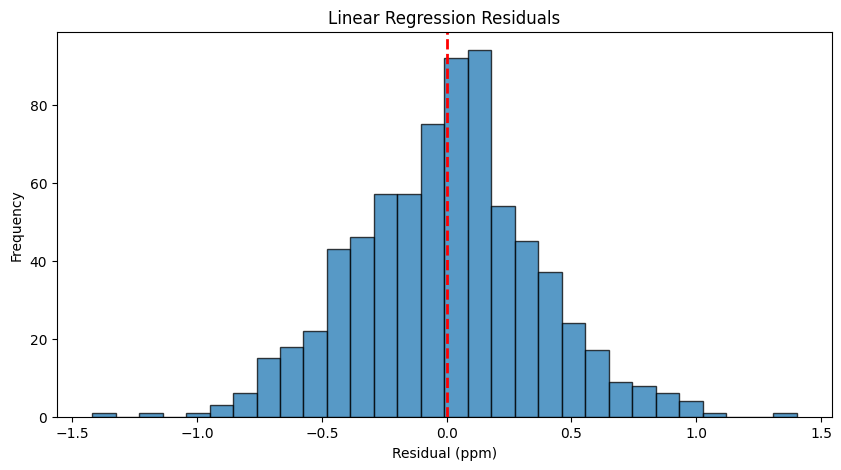

In [27]:
# ============================================================
# Residual Distribution
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Linear Regression Residuals")
plt.xlabel("Residual (ppm)")
plt.ylabel("Frequency")

plt.show()


In [29]:
# ============================================================
# Recursive 24-Month Forecast
# ============================================================

forecast_months = 24

# Start with the complete observed training history
history = train["average"].copy()

# Last observed date in training data
last_date = history.index[-1]

# Future monthly dates
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=forecast_months,
    freq="MS"
)


# ------------------------------------------------------------
# Function to create features for one future date
# ------------------------------------------------------------

def create_future_features(date, history):
    
    month = date.month

    features = {
        "month_sin": np.sin(
            2 * np.pi * month / 12
        ),

        "month_cos": np.cos(
            2 * np.pi * month / 12
        ),

        "lag_1": history.iloc[-1],

        "lag_2": history.iloc[-2],

        "lag_3": history.iloc[-3],

        "lag_6": history.iloc[-6],

        "lag_8": history.iloc[-8],

        "lag_10": history.iloc[-10],

        "lag_12": history.iloc[-12],

        "rolling_mean_12": history.iloc[-12:].mean(),

        "rolling_std_12": history.iloc[-12:].std()
    }

    return pd.DataFrame(
        [features],
        index=[date]
    )[feature_columns]


# ------------------------------------------------------------
# Recursive forecasting
# ------------------------------------------------------------

forecast_values = []

forecast_history = history.copy()


for date in future_dates:

    # Create features using currently available history
    X_future = create_future_features(
        date,
        forecast_history
    )

    # Predict next month
    prediction = final_linear_model.predict(
        X_future
    )[0]

    # Store prediction
    forecast_values.append(prediction)

    # Add prediction to history
    # so that it becomes available for later lags
    forecast_history.loc[date] = prediction


# Convert to Series
forecast = pd.Series(
    forecast_values,
    index=future_dates,
    name="forecast"
)

display(forecast)


2024-08-01    423.425557
2024-09-01    422.138922
2024-10-01    421.937080
2024-11-01    423.142870
2024-12-01    424.659636
2025-01-01    426.191528
2025-02-01    427.269535
2025-03-01    428.221712
2025-04-01    429.183344
2025-05-01    429.714543
2025-06-01    429.475814
2025-07-01    428.135440
2025-08-01    426.363565
2025-09-01    425.018885
2025-10-01    424.891643
2025-11-01    425.940174
2025-12-01    427.538623
2026-01-01    429.083804
2026-02-01    430.264183
2026-03-01    431.261731
2026-04-01    432.114604
2026-05-01    432.598716
2026-06-01    432.265066
2026-07-01    430.999396
Freq: MS, Name: forecast, dtype: float64

In [30]:
# ============================================================
# Bootstrap 95% Prediction Interval
# ============================================================

n_simulations = 2000

rng = np.random.default_rng(42)

simulation_paths = np.zeros(
    (n_simulations, forecast_months)
)


for simulation in range(n_simulations):

    # Start from the actual observed training history
    sim_history = history.copy()

    for step, date in enumerate(future_dates):

        # Create future features
        X_future = create_future_features(
            date,
            sim_history
        )

        # Base model prediction
        prediction = final_linear_model.predict(
            X_future
        )[0]

        # Randomly sample a historical residual
        error = rng.choice(
            residuals
        )

        # Add uncertainty
        simulated_prediction = (
            prediction + error
        )

        # Store simulated prediction
        simulation_paths[
            simulation,
            step
        ] = simulated_prediction

        # Add simulated observation to history
        sim_history.loc[date] = (
            simulated_prediction
        )


# ------------------------------------------------------------
# Calculate prediction interval
# ------------------------------------------------------------

forecast_lower = np.percentile(
    simulation_paths,
    2.5,
    axis=0
)

forecast_upper = np.percentile(
    simulation_paths,
    97.5,
    axis=0
)


# ------------------------------------------------------------
# Create final forecast DataFrame
# ------------------------------------------------------------

forecast_results = pd.DataFrame({
    "Forecast": forecast.values,
    "Lower_95": forecast_lower,
    "Upper_95": forecast_upper
}, index=future_dates)


display(
    forecast_results.round(2)
)


,Forecast,Lower_95,Upper_95
2024-08-01,423.43,422.75,424.15
2024-09-01,422.14,421.32,423.02
2024-10-01,421.94,421.06,422.86
2024-11-01,423.14,422.17,424.15
2024-12-01,424.66,423.69,425.66
2025-01-01,426.19,425.24,427.20
2025-02-01,427.27,426.27,428.30
2025-03-01,428.22,427.03,429.38
2025-04-01,429.18,428.07,430.35
2025-05-01,429.71,428.59,430.84


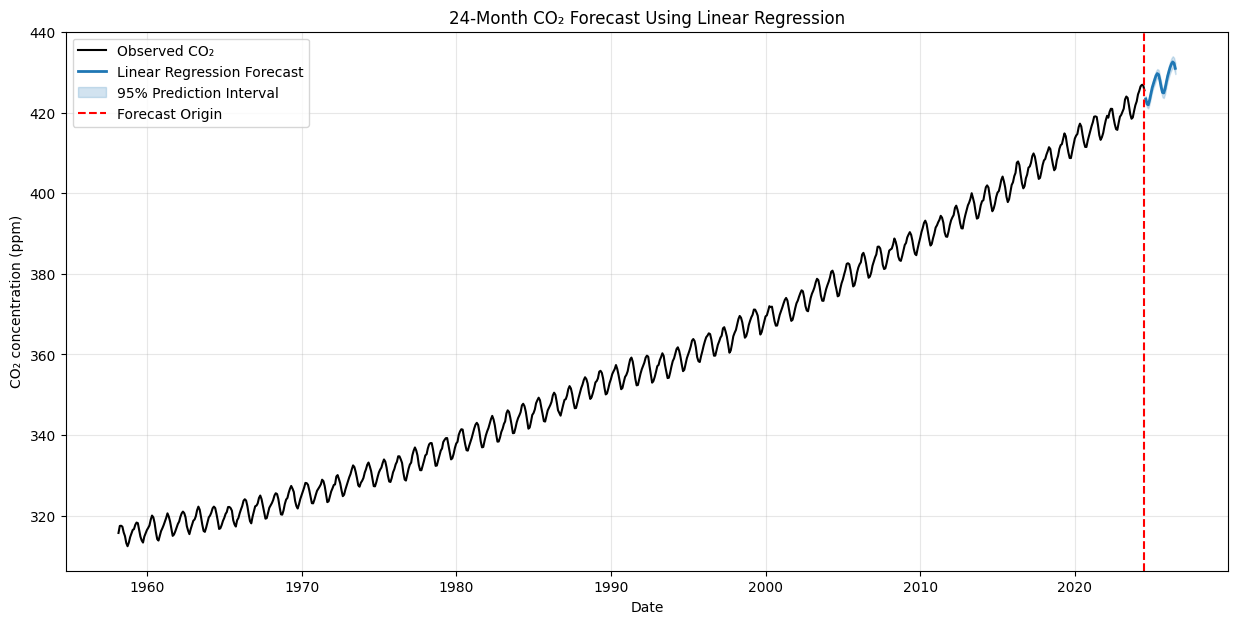

In [31]:
# ============================================================
# Plot 24-Month Forecast with 95% Prediction Interval
# ============================================================

plt.figure(figsize=(15, 7))

# Historical training observations
plt.plot(
    train.index,
    train["average"],
    label="Observed CO₂",
    color="black",
    linewidth=1.5
)

# Forecast
plt.plot(
    forecast_results.index,
    forecast_results["Forecast"],
    label="Linear Regression Forecast",
    color="tab:blue",
    linewidth=2
)

# 95% prediction interval
plt.fill_between(
    forecast_results.index,
    forecast_results["Lower_95"],
    forecast_results["Upper_95"],
    color="tab:blue",
    alpha=0.2,
    label="95% Prediction Interval"
)

# Forecast starting point
plt.axvline(
    train.index[-1],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Forecast Origin"
)

plt.title(
    "24-Month CO₂ Forecast Using Linear Regression"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [32]:
# ============================================================
# Compare Forecast Against 24-Month Holdout
# ============================================================

comparison = pd.DataFrame({
    "Actual": holdout["average"],
    "Forecast": forecast_results["Forecast"],
    "Lower_95": forecast_results["Lower_95"],
    "Upper_95": forecast_results["Upper_95"]
})

comparison["Error"] = (
    comparison["Actual"]
    - comparison["Forecast"]
)

comparison["Absolute_Error"] = (
    comparison["Error"].abs()
)

display(
    comparison.round(2)
)


,Actual,Forecast,Lower_95,Upper_95,Error,Absolute_Error
2024-08-01,422.99,423.43,422.75,424.15,-0.44,0.44
2024-09-01,422.03,422.14,421.32,423.02,-0.11,0.11
2024-10-01,422.38,421.94,421.06,422.86,0.44,0.44
2024-11-01,423.85,423.14,422.17,424.15,0.71,0.71
2024-12-01,425.40,424.66,423.69,425.66,0.74,0.74
2025-01-01,426.65,426.19,425.24,427.20,0.46,0.46
2025-02-01,427.09,427.27,426.27,428.30,-0.18,0.18
2025-03-01,428.15,428.22,427.03,429.38,-0.07,0.07
2025-04-01,429.64,429.18,428.07,430.35,0.46,0.46
2025-05-01,430.51,429.71,428.59,430.84,0.80,0.80


In [33]:
# ============================================================
# Final Holdout Performance
# ============================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

actual = comparison["Actual"]
predicted = comparison["Forecast"]


holdout_rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

holdout_mae = mean_absolute_error(
    actual,
    predicted
)

holdout_r2 = r2_score(
    actual,
    predicted
)

holdout_mape = (
    np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    )
    * 100
)


holdout_metrics = pd.DataFrame({
    "RMSE": [holdout_rmse],
    "MAE": [holdout_mae],
    "R2": [holdout_r2],
    "MAPE": [holdout_mape]
}, index=["Linear Regression"])


display(
    holdout_metrics.round(4)
)


,RMSE,MAE,R2,MAPE
Linear Regression,0.6968,0.5569,0.9422,0.1301


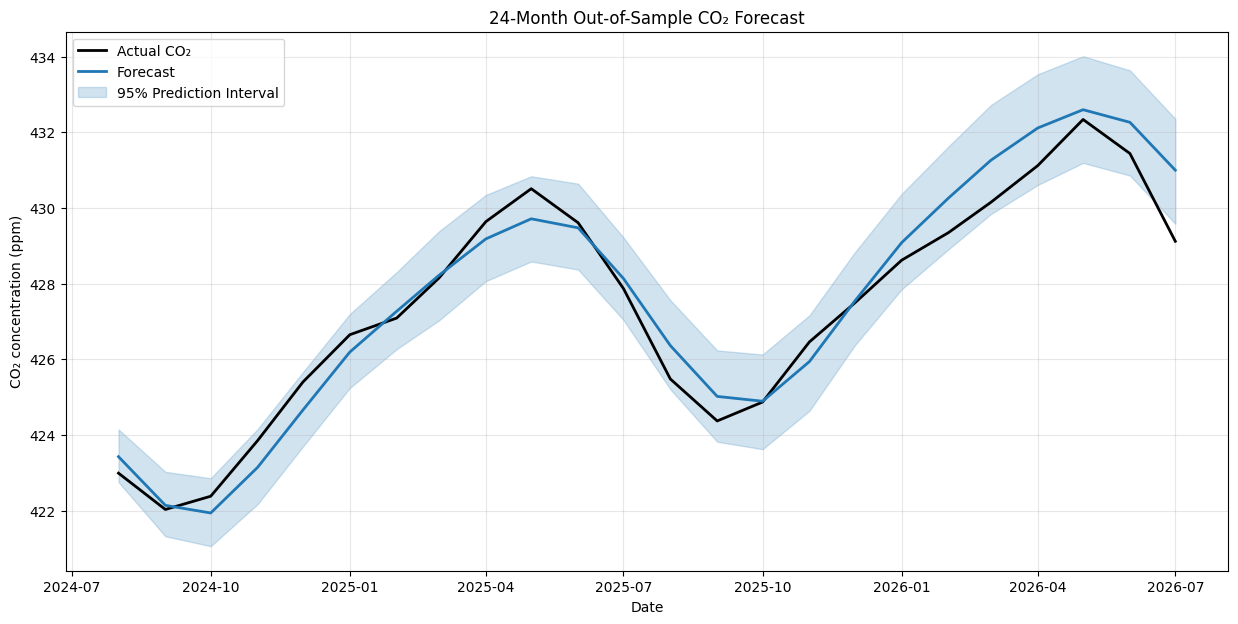

In [34]:
# ============================================================
# Holdout Forecast vs Actual
# ============================================================

plt.figure(figsize=(15, 7))

plt.plot(
    comparison.index,
    comparison["Actual"],
    label="Actual CO₂",
    color="black",
    linewidth=2
)

plt.plot(
    comparison.index,
    comparison["Forecast"],
    label="Forecast",
    color="tab:blue",
    linewidth=2
)

plt.fill_between(
    comparison.index,
    comparison["Lower_95"],
    comparison["Upper_95"],
    color="tab:blue",
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.title(
    "24-Month Out-of-Sample CO₂ Forecast"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


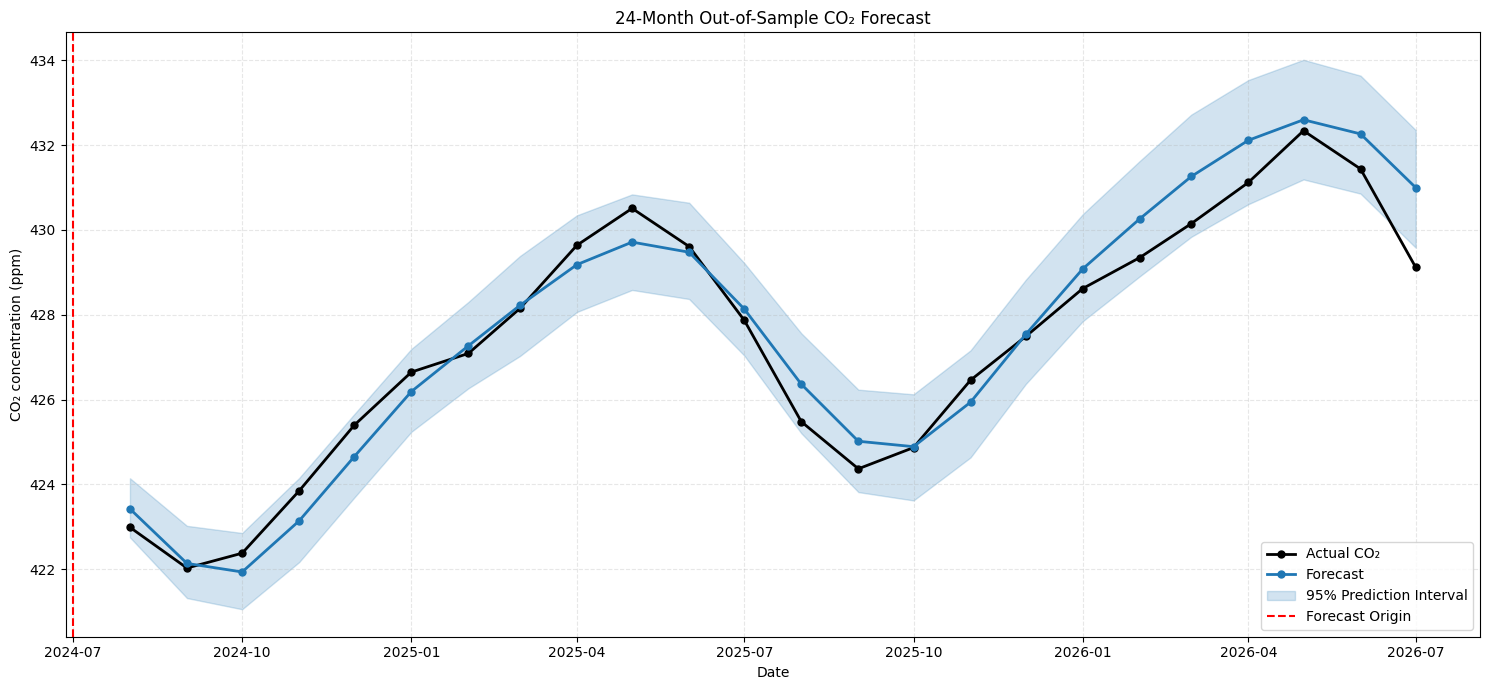

In [35]:
# ============================================================
# Holdout Forecast vs Actual - Monthly Observations
# ============================================================

plt.figure(figsize=(15, 7))

# Actual CO₂ observations
plt.plot(
    comparison.index,
    comparison["Actual"],
    label="Actual CO₂",
    color="black",
    linewidth=2,
    marker="o",
    markersize=5
)

# Forecasted CO₂ observations
plt.plot(
    comparison.index,
    comparison["Forecast"],
    label="Forecast",
    color="tab:blue",
    linewidth=2,
    marker="o",
    markersize=5
)

# 95% prediction interval
plt.fill_between(
    comparison.index,
    comparison["Lower_95"],
    comparison["Upper_95"],
    color="tab:blue",
    alpha=0.2,
    label="95% Prediction Interval"
)

# Forecast origin
plt.axvline(
    train.index[-1],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Forecast Origin"
)

plt.title(
    "24-Month Out-of-Sample CO₂ Forecast"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")

plt.legend()
plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.tight_layout()

plt.show()
